### Exercise: 
Simulate the Monty Hall Problem

You are playing a TV game show and are shown 2 doors.  One has a car behind it, the other a goat.  What are your chances of picking the door with the car?
**Risposta: 50%**

OK, now there are 3 doors: one with a car, two with goats.  The game show host asks you to pick a door, but not to open it yet.  Then the host opens one of the other two doors (that you did not pick) and that has a goat.  The host offers you the opportunity to switch doors.

- One player decides to switch **lo chiameremo "SWITCHER"**
- Another player prefers to stay with the previous choice **lo chiameremo "CONSERVATIVE"**
- Now a third player comes in who has not seen what happened earlier. They pick a door. **lo chiameremo "NEWCOMER"**

Which of the three players is most likely to win?

- Simulate three doors, one car, and two goats. (an array with 1 1 0 in random spots)
 - Simulate three players: the switcher (decides to switch), the conservative (stick on that), and the newcomer (never seen anything, comes in and see 2 closed doors and one with an open goat). 
 - Record who wins.
 - Repeat it many times.
 - Which player do you want to be?
 

**Food for thought:** And what if you had $N$ doors to choose from and the presenter opens $p\leq N$ of them? Study how the probability of winning changes as a function of $p$ and $N$.

In [2]:
#Importiamo le librerie
import numpy as np
import random
import pylab as plt

#inizializziamo le variabili
trials = int(1e5) #numero di tentativi
s_wins = 0 #numero di vincite dello switcher player
c_wins = 0 #numero di vincite del conservative player
n_wins = 0 #numero di vincite del newcomer

index_array = np.array([0,1,2]) #indici delle porte

#Implementiamo il for per il tentativo

#0 = capra
#1 = macchina

for j in range(trials):
    random_doors = np.array([1]*1 + [0]*2)
    np.random.shuffle(random_doors) #generiamo un array con valori disposti random tra due capre e una macchina


    #facciamo una scelta random tra le tre porte
    player_door = np.random.choice(index_array)

    #implementiamo la logica del conduttore
    possible_conductor_door = [] #quale porta può scegliere il conduttore?
    for i in range(len(random_doors)):
        if(i != player_door and random_doors[i] == 0):
            possible_conductor_door.append(i)

    conductor_door = np.random.choice(possible_conductor_door)
    
    #ora implementiamo i vari giocatori

    #switcher
    s_door = 0
    for i in range(len(random_doors)):
        if i!=player_door and i != conductor_door:
            s_door = i

    #ha vinto?
    if random_doors[s_door] == 1:
        s_wins = s_wins + 1


    #conservative
    c_door = player_door
    if random_doors[c_door] == 1:
        c_wins = c_wins + 1

    #newcomer
    n_door = np.random.choice([s_door, player_door]) #sceglie tra le due rimanenti
    if random_doors[n_door] == 1:
        n_wins = n_wins + 1
    
#SIMULAZIONE FINITA

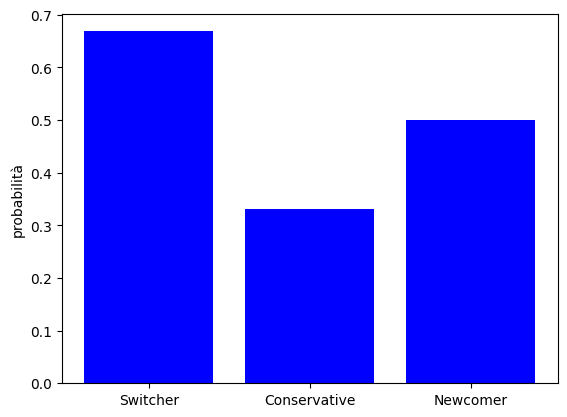

In [3]:
#vediamo i risultati
probs = [s_wins/trials, c_wins/trials, n_wins/trials]
nomi = ["Switcher", "Conservative", "Newcomer"]

plt.bar([0, 1, 2], probs, color='blue')
plt.xticks([0, 1, 2], nomi)
plt.ylabel('probabilità')
plt.savefig("./Images/EX_1_Histogram.png")

In [4]:
#Osserviamo 7 casi con N porte che variano e per ciascun caso vediamo 4 valori possibili di porte aperte p che vengono aperte (un quarto, metà, 3/4, 90%)
trials = int(0.5e4)
N_list = [int(3),int(10),int(30),int(50),int(100),int(1000)]
index_arrays = [np.arange(n) for n in N_list] #contiene 7 array con gli indici di ciascuna porta sulla riga 
p_doors = [0.25, 0.5, 0.75, 0.9] #un array con le diverse frazioni di porte aperte

#definiamo le matrici N x p che contengono le vittorie con N porte di cui p aperte su "trials" tentativi
s_wins_mat = np.zeros((len(N_list), len(p_doors)))
c_wins_mat = np.zeros((len(N_list), len(p_doors)))
n_wins_mat = np.zeros((len(N_list), len(p_doors)))

#primo for sul numero di porte
for i in range(len(N_list)): #numero di porte
    N = N_list[i] 
    current_indices = index_arrays[i]
    #secondo for sul numero di porte aperte
    for j in range(len(p_doors)): #numero di porte aperte
        frac = p_doors[j] #prendiamo il valore di frazione di porte
        p_eff = int(frac * int(N-1)) #l'effettivo numero di porte aperte per il caso con N porte e frac 

        #valori di conteggio
        s_count = 0
        c_count = 0
        n_count = 0

        #for sui tentativi
        for k in range(trials):
            random_doors = np.array([1]*1 + [0]*int(N-1)) #inseriamo una macchina sulle N porte e N-1 capre
            np.random.shuffle(random_doors) #randomizziamo

            player_door = np.random.choice(current_indices)

            #un array per capire quali sono le possibili porte apribili dal conducente
            possible_conductor_door = []
            for idx in current_indices:
                if( idx != player_door and random_doors[int(idx)] != 1):
                    possible_conductor_door.append(idx)

            #apriamo le porte 
            opened = np.random.choice(possible_conductor_door, p_eff, replace = False) #false = non possiamo pescare più volte la stessa porta
            closed = []
            for idx in current_indices:
                if( idx != player_door and idx not in opened):
                    closed.append(idx)

            #switcher
            s_choice = np.random.choice(closed)
            if random_doors[s_choice] == 1:
                s_count = s_count + 1

            #conservative
            if random_doors[player_door] == 1:
                c_count = c_count + 1

            #newcomer
            n_choice = np.random.choice(closed)
            if random_doors[n_choice] == 1:
                n_count = n_count + 1

        print("Finito N = "+ str(N) + " p = " + str(p_eff))

        #aggiorniamo le matrici
        s_wins_mat[i, j] = s_count/trials
        c_wins_mat[i, j] = c_count/trials
        n_wins_mat[i, j] = n_count/trials
        
print("Simulazione completata.")            

Finito N = 3 p = 0
Finito N = 3 p = 1
Finito N = 3 p = 1
Finito N = 3 p = 1
Finito N = 10 p = 2
Finito N = 10 p = 4
Finito N = 10 p = 6
Finito N = 10 p = 8
Finito N = 30 p = 7
Finito N = 30 p = 14
Finito N = 30 p = 21
Finito N = 30 p = 26
Finito N = 50 p = 12
Finito N = 50 p = 24
Finito N = 50 p = 36
Finito N = 50 p = 44
Finito N = 100 p = 24
Finito N = 100 p = 49
Finito N = 100 p = 74
Finito N = 100 p = 89
Finito N = 1000 p = 249
Finito N = 1000 p = 499
Finito N = 1000 p = 749
Finito N = 1000 p = 899
Simulazione completata.


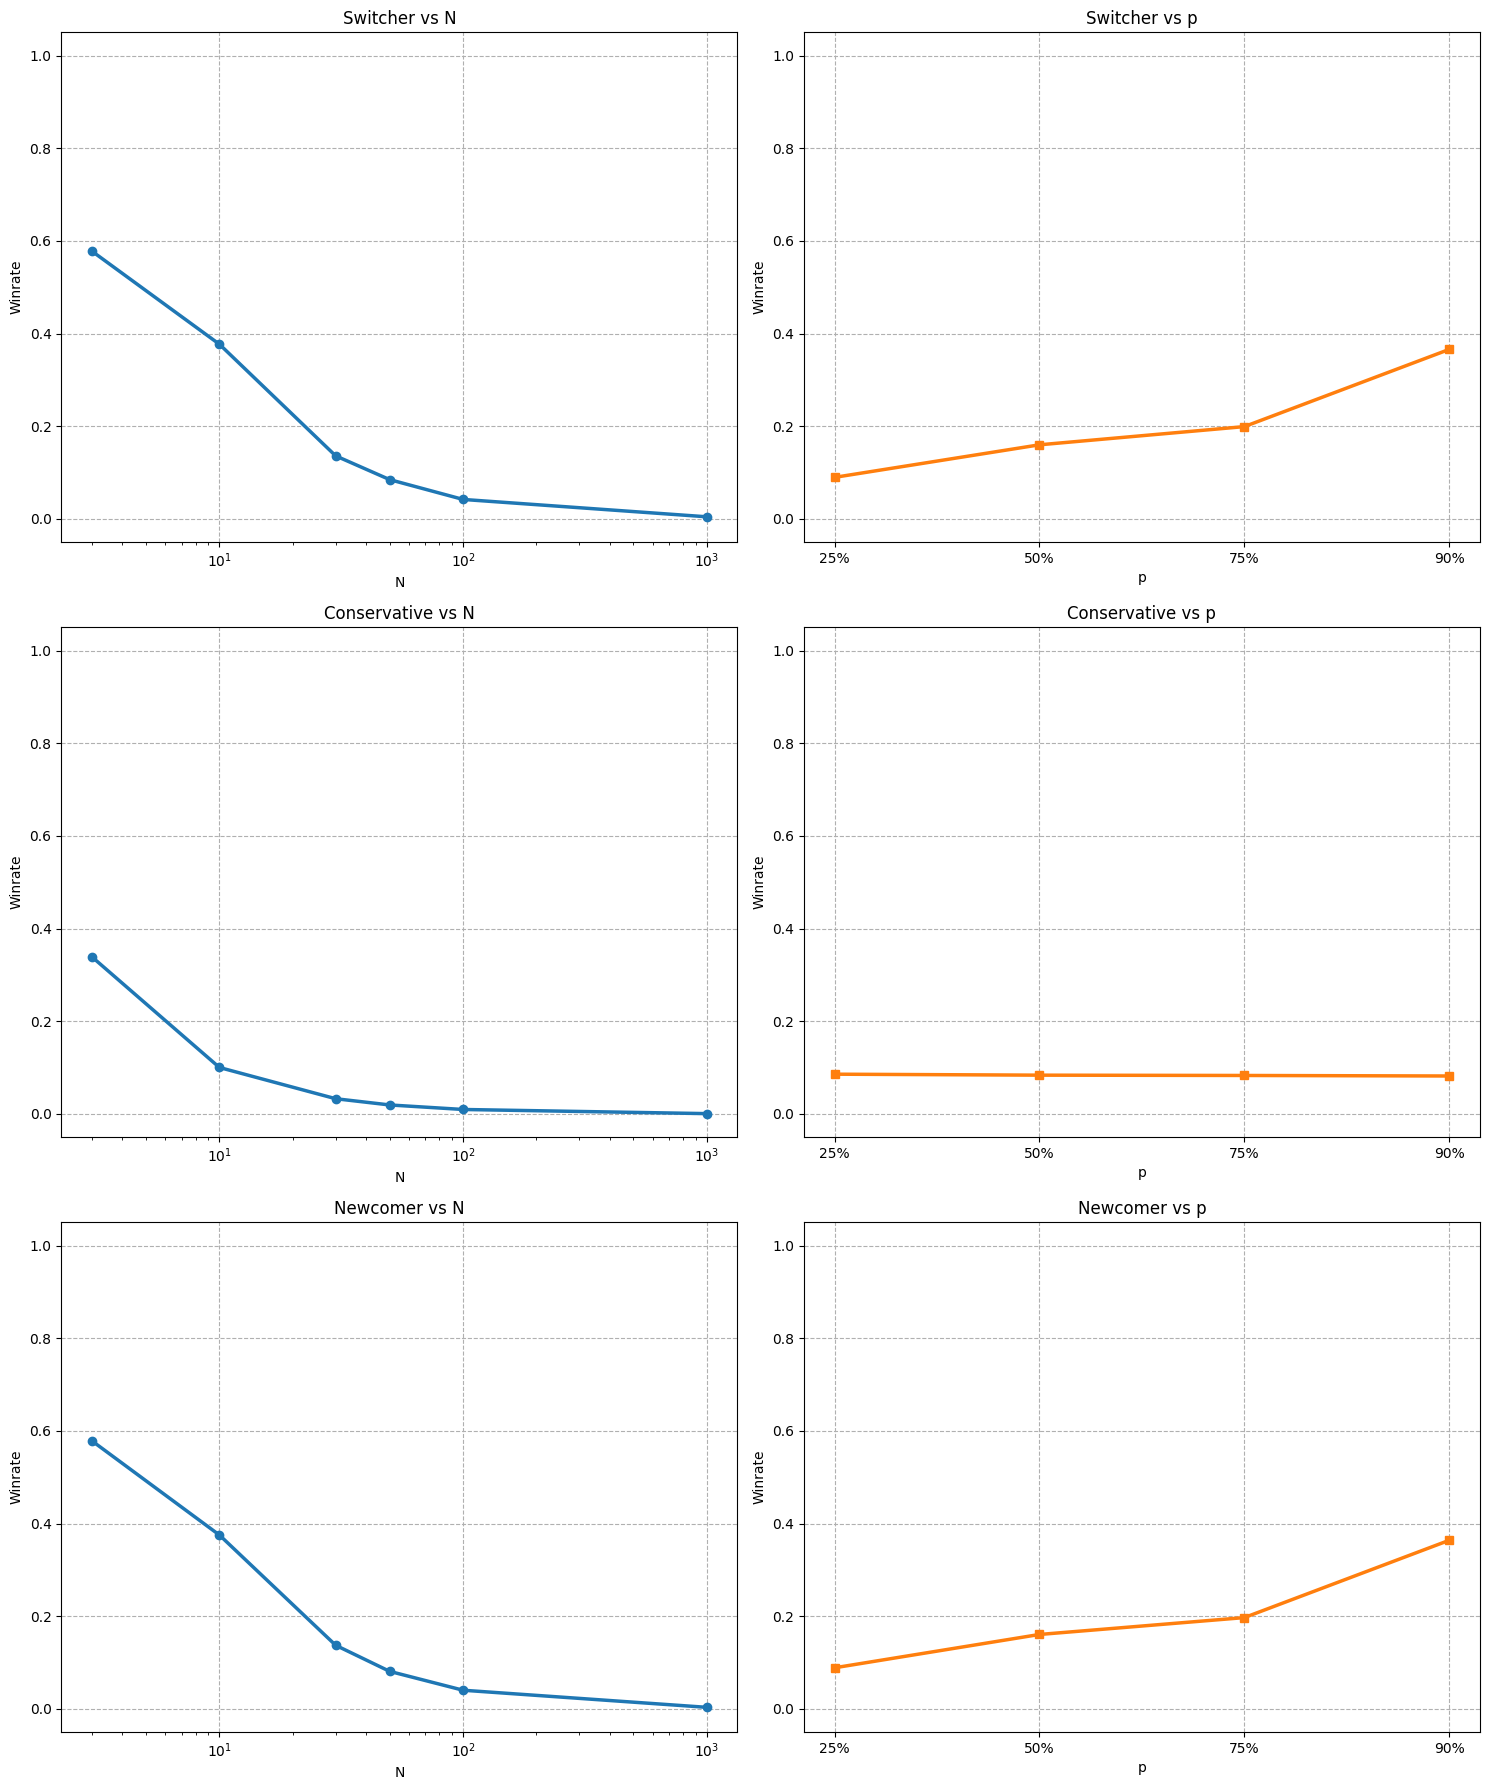

In [5]:
import matplotlib.pyplot as plt
#Andiamo a fare due probabilità marginali per ogni strategia, ovvero marginalizziamo rispetto a N e rispetto a p.
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

titles = ["Switcher", "Conservative", "Newcomer"]
matrices = [s_wins_mat, c_wins_mat, n_wins_mat]

p_labels = [f"{int(p*100)}%" for p in p_doors]

for i in range(3):
    win_mat = matrices[i]

    #marginalizziamo per N
    ax_N = axes[i, 0]
    
    #mediamo sulle porte aperte così marginalizziamo sulla colonna
    marginal_N = win_mat.mean(axis=1) 
    
    ax_N.plot(N_list, marginal_N, marker='o', linewidth=2.5, color='C0', label='marginale rispetto a N')
    ax_N.set_title(f"{titles[i]} vs N")
    ax_N.set_xlabel("N")
    ax_N.set_ylabel("Winrate")
    ax_N.set_xscale('log')
    ax_N.set_ylim(-0.05, 1.05)
    ax_N.grid(True, ls="--")

    # marginalizziamo per p
    ax_p = axes[i, 1]
    
    # eliminiamo la dipendenza da N
    marginal_p = win_mat.mean(axis=0) 
    
    ax_p.plot(p_labels, marginal_p, marker='s', linewidth=2.5, color='C1', label='marginale rispetto a p')
    ax_p.set_title(f"{titles[i]} vs p")
    ax_p.set_xlabel("p")
    ax_p.set_ylabel("Winrate")
    ax_p.set_ylim(-0.05, 1.05)
    ax_p.grid(True, ls="--")

plt.tight_layout()
plt.savefig("./Images/EX_1_Marginals.png")
plt.show()